Part 2.3 - QuickDraw Pizza DCGAN

1. Imports & Setup

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import linalg
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


2. Load QuickDraw Pizza Dataset

In [ ]:
NPY_PATH = '/kaggle/input/datasets/suteshl/pizza-dataset/pizza.npy'  # update path if needed

data = np.load(NPY_PATH)
print(f'Raw shape: {data.shape} | Value range: [{data.min()}, {data.max()}]')


Raw shape: (130371, 784) | Value range: [0, 255]


3. Normalise and Show Sample Sketches

Shape: (130371, 1, 28, 28) | Range: [-1.00, 1.00]


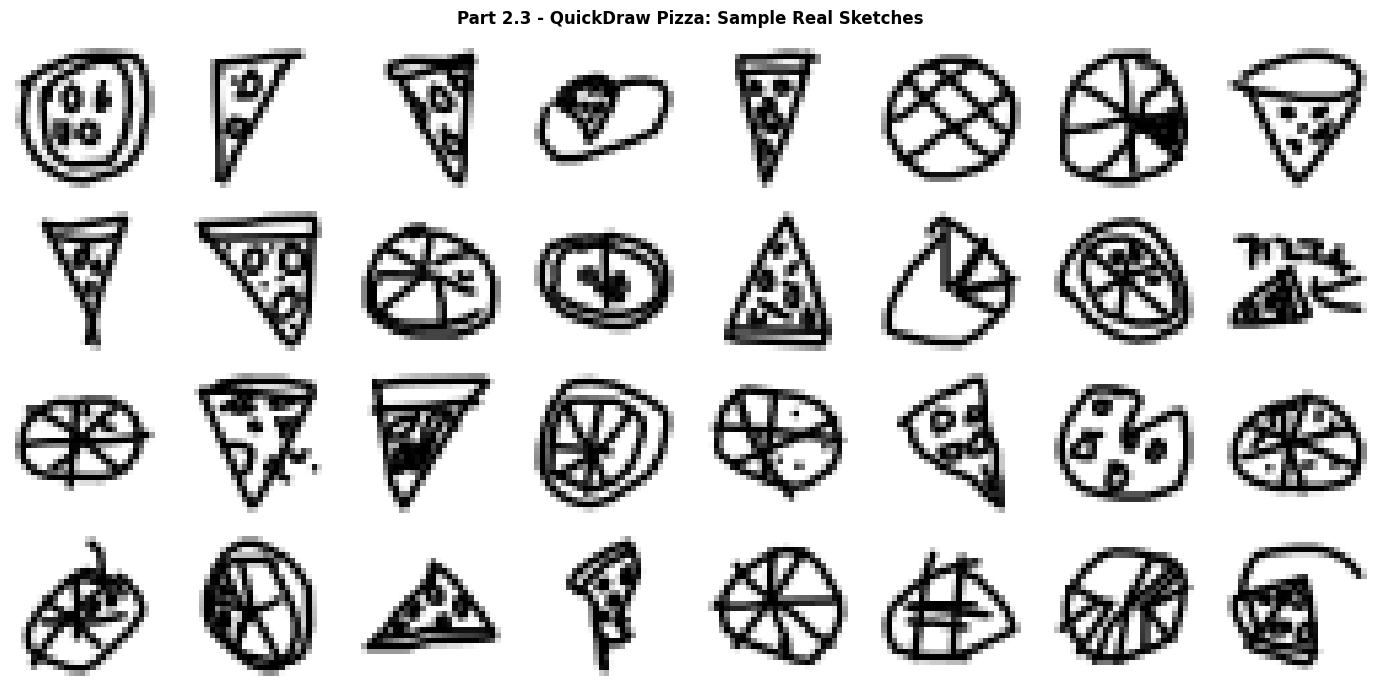

In [ ]:
data_norm = (data.astype(np.float32)/255.0 - 0.5)/0.5  # uint8 [0,255] -> [-1,1]
data_imgs = data_norm.reshape(-1,1,28,28)
print(f'Shape: {data_imgs.shape} | Range: [{data_imgs.min():.2f}, {data_imgs.max():.2f}]')

idx    = np.random.choice(len(data_imgs),32,replace=False)
sample = data_imgs[idx]
fig, axes = plt.subplots(4,8, figsize=(14,7))
axes = axes.flatten()
for i in range(32):
    axes[i].imshow((sample[i,0]*0.5+0.5), cmap='gray_r', vmin=0, vmax=1)
    axes[i].axis('off')
plt.suptitle('Part 2.3 - QuickDraw Pizza: Sample Real Sketches', fontweight='bold')
plt.tight_layout(); plt.show()


4. Create DataLoader

In [ ]:
N_SAMPLES  = 50000  # use more samples since GPU is fast
BATCH_SIZE = 128

subset      = data_imgs[:N_SAMPLES]
tensor      = torch.from_numpy(subset)
labels      = torch.zeros(N_SAMPLES)
dataset     = TensorDataset(tensor, labels)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=True, num_workers=2, pin_memory=True)
print(f'Samples: {N_SAMPLES} | Batches/epoch: {len(train_loader)}')


Samples: 50000 | Batches/epoch: 390


5. DCGAN Model Definitions (Grayscale)

In [ ]:
LATENT_DIM = 100

class DCGANGenerator(nn.Module):
    def __init__(self, latent_dim=100, channels=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim,256*7*7),
            nn.Unflatten(1,(256,7,7)),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1),  # 7->14
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128,channels,4,2,1),  # 14->28
            nn.Tanh(),
        )
    def forward(self,z): return self.net(z)


class DCGANDiscriminator(nn.Module):
    def __init__(self, channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(channels,128,4,2,1), nn.LeakyReLU(0.2),
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Flatten(),
        )
        self.classifier = nn.Sequential(nn.Linear(256*7*7,1), nn.Sigmoid())
    def forward(self,x): return self.classifier(self.features(x))
    def extract_features(self,x): return self.features(x)


def init_weights(m):
    if isinstance(m,(nn.Conv2d,nn.ConvTranspose2d,nn.Linear)):
        nn.init.normal_(m.weight,0.0,0.02)
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m,nn.BatchNorm2d):
        nn.init.normal_(m.weight,1.0,0.02); nn.init.zeros_(m.bias)


generator     = DCGANGenerator(LATENT_DIM,channels=1).to(DEVICE)
discriminator = DCGANDiscriminator(channels=1).to(DEVICE)
generator.apply(init_weights); discriminator.apply(init_weights)
print(f'Generator     : {sum(p.numel() for p in generator.parameters()):,} params')
print(f'Discriminator : {sum(p.numel() for p in discriminator.parameters()):,} params')


Generator     : 1,794,177 params
Discriminator : 539,777 params


6. Training Setup

In [ ]:
LR         = 0.0002
BETAS      = (0.5, 0.999)
NUM_EPOCHS = 50

loss_fn = nn.BCELoss()
opt_G   = torch.optim.Adam(generator.parameters(),     lr=LR,     betas=BETAS)
opt_D   = torch.optim.Adam(discriminator.parameters(), lr=LR*0.5, betas=BETAS)

fixed_noise = torch.randn(32, LATENT_DIM, device=DEVICE)
print(f'LR={LR} | Epochs={NUM_EPOCHS} | Batch={BATCH_SIZE}')


LR=0.0002 | Epochs=50 | Batch=128


7. Train DCGAN

In [ ]:
def train_dcgan(generator, discriminator, loader, opt_G, opt_D,
                loss_fn, num_epochs, latent_dim, device, fixed_noise,
                print_every=5, snapshot_epochs=None):
    g_losses, d_losses, snapshots = [], [], {}
    for epoch in range(num_epochs):
        g_epoch, d_epoch, n = 0.0, 0.0, 0
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device, non_blocking=True)
            bs = real_imgs.size(0)
            real_labels = torch.full((bs,1), 0.9, device=device)  # label smoothing
            fake_labels = torch.zeros(bs, 1, device=device)

            z         = torch.randn(bs, latent_dim, device=device)
            fake_imgs = generator(z).detach()
            loss_d    = loss_fn(discriminator(real_imgs), real_labels) + \
                        loss_fn(discriminator(fake_imgs), fake_labels)
            opt_D.zero_grad(); loss_d.backward(); opt_D.step()

            z         = torch.randn(bs, latent_dim, device=device)
            fake_imgs = generator(z)
            loss_g    = loss_fn(discriminator(fake_imgs), torch.ones(bs,1,device=device))
            opt_G.zero_grad(); loss_g.backward(); opt_G.step()

            g_epoch += loss_g.item(); d_epoch += loss_d.item(); n += 1

        g_losses.append(g_epoch/n); d_losses.append(d_epoch/n)

        if snapshot_epochs and (epoch+1) in snapshot_epochs:
            generator.eval()
            with torch.no_grad(): imgs = generator(fixed_noise).cpu()
            generator.train()
            snapshots[epoch+1] = imgs

        if (epoch+1) % print_every == 0:
            print(f'Epoch {epoch+1:3d}/{num_epochs} | Loss G: {g_losses[-1]:.4f} | Loss D: {d_losses[-1]:.4f}')

    return g_losses, d_losses, snapshots


SNAPSHOT_EPOCHS = [1, 10, 25, 50]
g_losses, d_losses, snapshots = train_dcgan(
    generator, discriminator, train_loader, opt_G, opt_D, loss_fn,
    NUM_EPOCHS, LATENT_DIM, DEVICE, fixed_noise,
    print_every=5, snapshot_epochs=SNAPSHOT_EPOCHS
)


Epoch   5/50 | Loss G: 2.5363 | Loss D: 0.5464
Epoch  10/50 | Loss G: 3.0360 | Loss D: 0.5076
Epoch  15/50 | Loss G: 3.1573 | Loss D: 0.4939
Epoch  20/50 | Loss G: 3.6753 | Loss D: 0.4155
Epoch  25/50 | Loss G: 3.2369 | Loss D: 0.5542
Epoch  30/50 | Loss G: 3.6305 | Loss D: 0.4470
Epoch  35/50 | Loss G: 3.5138 | Loss D: 0.4209
Epoch  40/50 | Loss G: 3.6229 | Loss D: 0.4260
Epoch  45/50 | Loss G: 3.6799 | Loss D: 0.4814
Epoch  50/50 | Loss G: 3.9696 | Loss D: 0.4382


8. Loss Curves

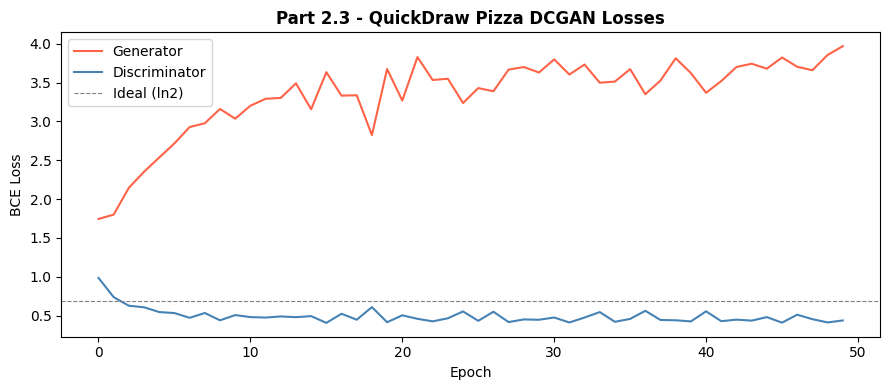

In [ ]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(g_losses, label='Generator',     color='tomato',    linewidth=1.5)
ax.plot(d_losses, label='Discriminator', color='steelblue', linewidth=1.5)
ax.axhline(y=math.log(2), color='grey', linestyle='--', linewidth=0.8, label='Ideal (ln2)')
ax.set_title('Part 2.3 - QuickDraw Pizza DCGAN Losses', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss'); ax.legend()
plt.tight_layout(); plt.show()


9. Training Progression Snapshots

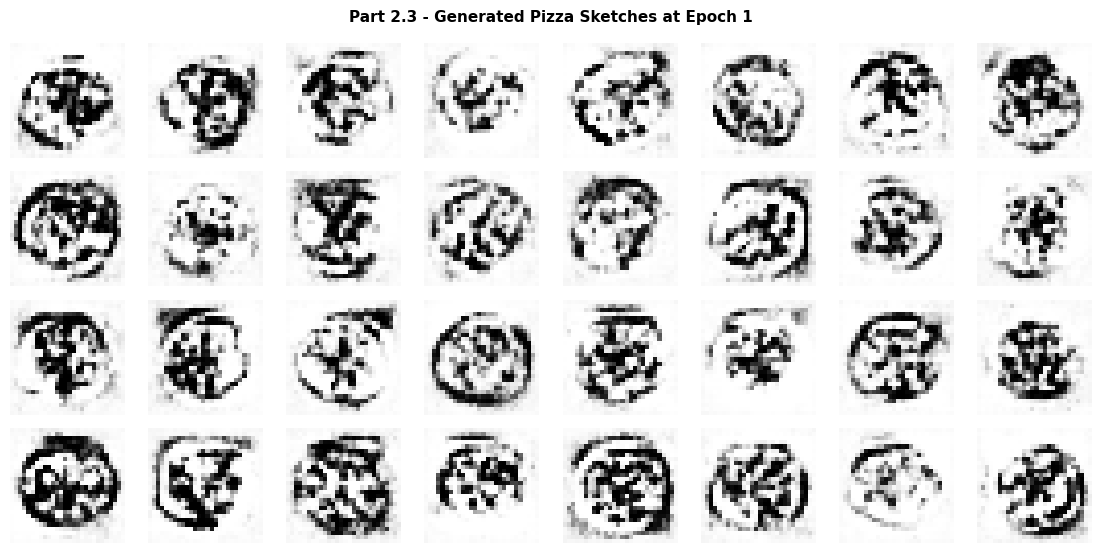

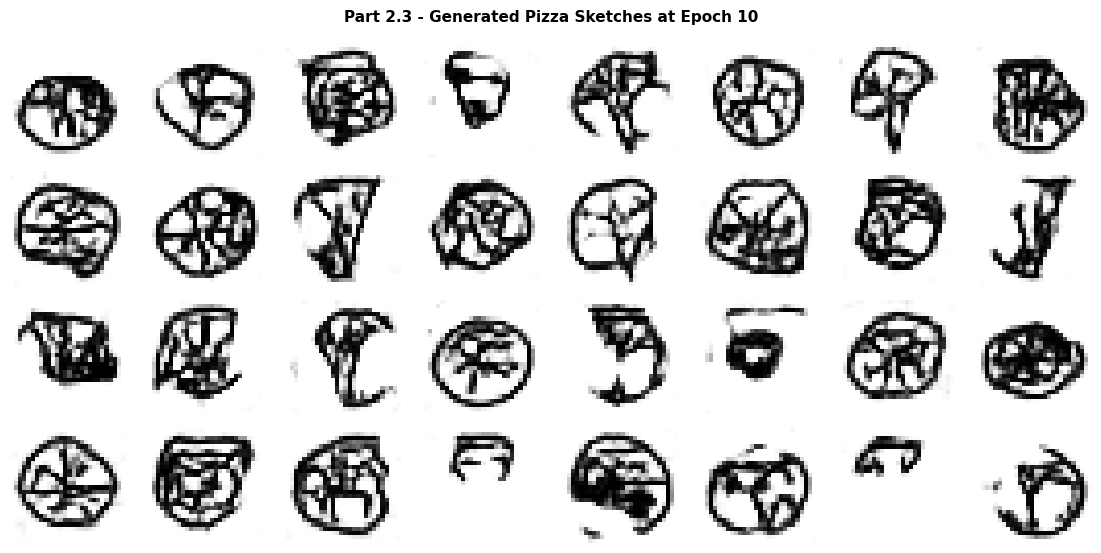

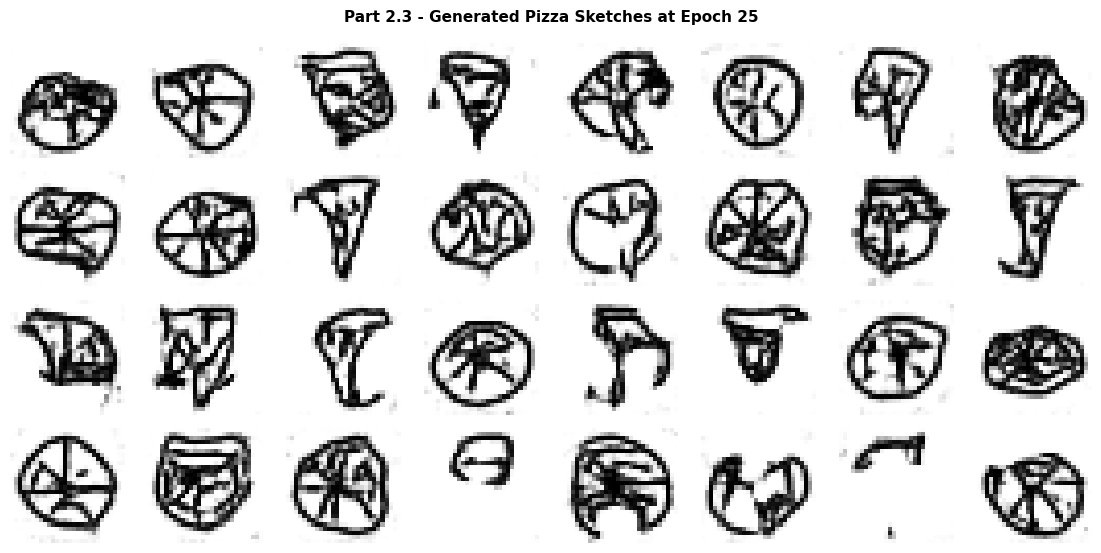

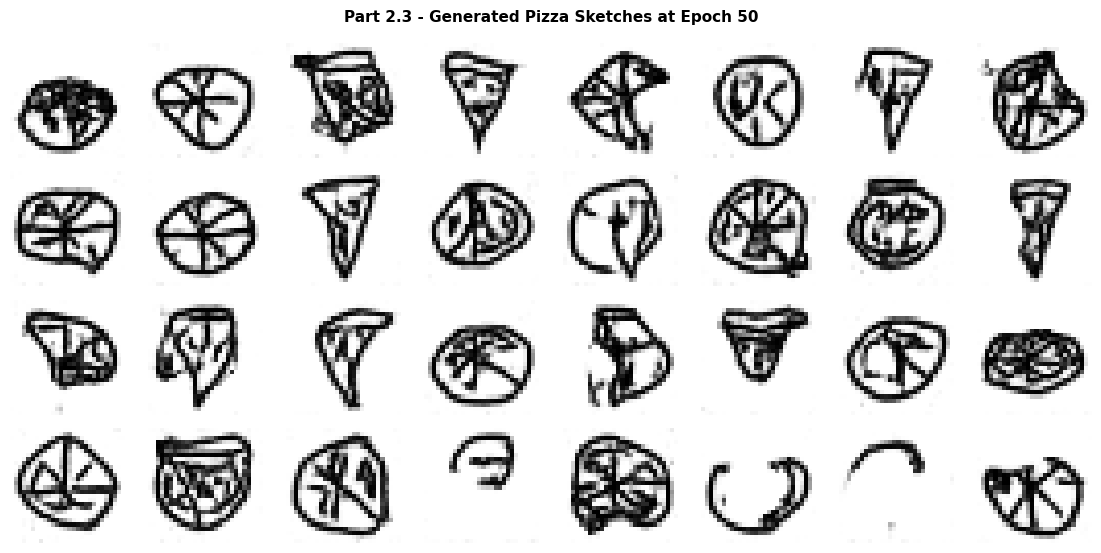

In [ ]:
def show_sketch_grid(imgs_tensor, title, n_cols=8):
    imgs   = (imgs_tensor*0.5+0.5).clamp(0,1)
    n      = min(len(imgs),32)
    n_rows = (n+n_cols-1)//n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*1.4, n_rows*1.4))
    axes = axes.flatten()
    for i in range(len(axes)):
        if i<n: axes[i].imshow(imgs[i,0].numpy(), cmap='gray_r', vmin=0, vmax=1)
        axes[i].axis('off')
    plt.suptitle(title, fontweight='bold', fontsize=11)
    plt.tight_layout(); plt.show()

for ep in SNAPSHOT_EPOCHS:
    if ep in snapshots:
        show_sketch_grid(snapshots[ep], f'Part 2.3 - Generated Pizza Sketches at Epoch {ep}')


10. Real vs Generated Comparison

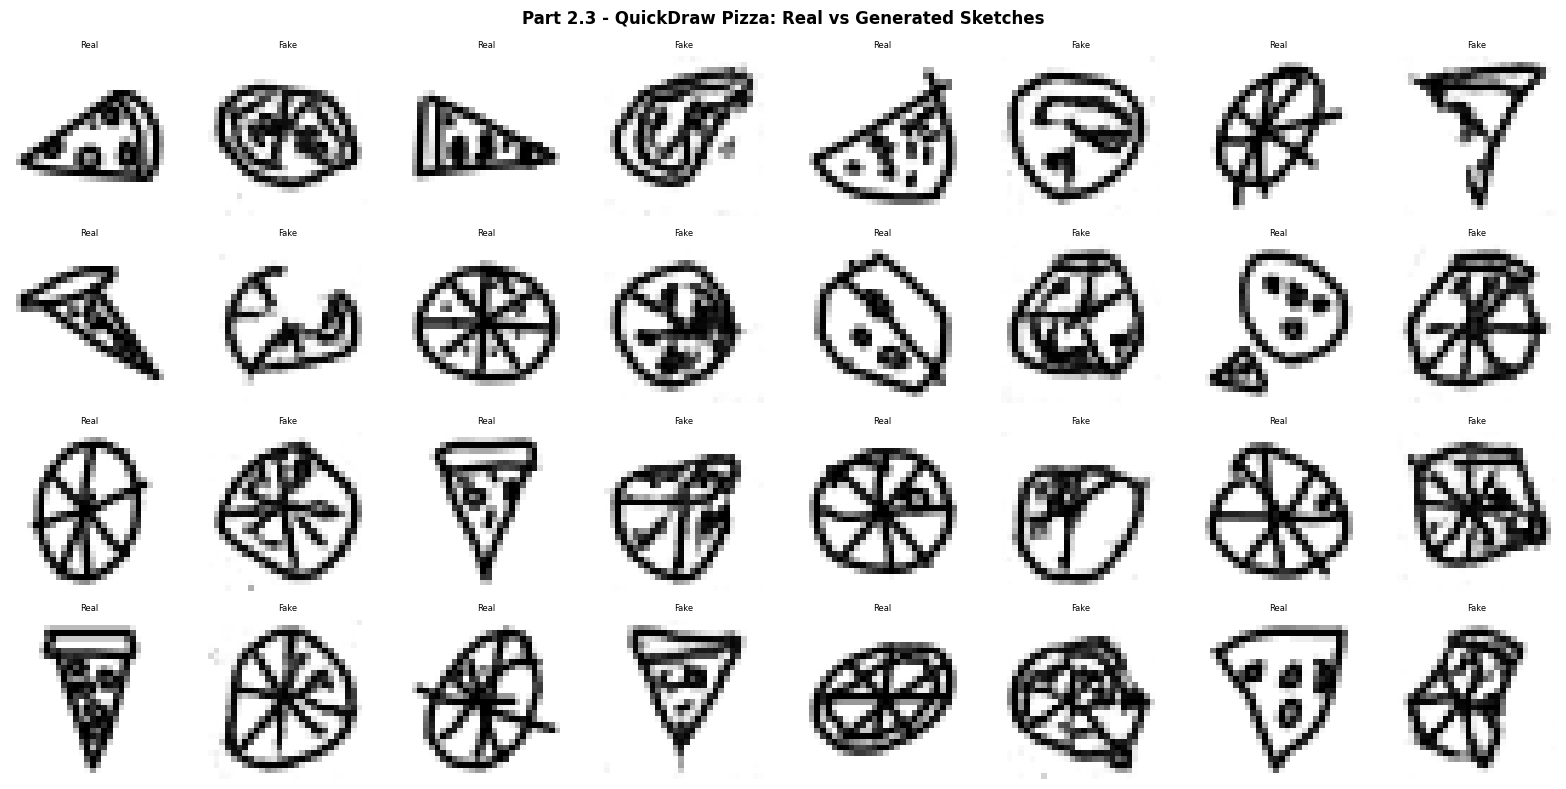

In [ ]:
generator.eval()
with torch.no_grad():
    final_fake = generator(torch.randn(32,LATENT_DIM,device=DEVICE)).cpu()
generator.train()

real_sample = tensor[:32]

fig, axes = plt.subplots(4,8, figsize=(16,8))
axes = axes.flatten()
for i in range(32):
    ax = axes[i]
    if i%2==0:
        img = (real_sample[i//2,0]*0.5+0.5).clamp(0,1).numpy()
        ax.imshow(img, cmap='gray_r', vmin=0, vmax=1); ax.set_title('Real', fontsize=6)
    else:
        img = (final_fake[i//2,0]*0.5+0.5).clamp(0,1).numpy()
        ax.imshow(img, cmap='gray_r', vmin=0, vmax=1); ax.set_title('Fake', fontsize=6)
    ax.axis('off')
plt.suptitle('Part 2.3 - QuickDraw Pizza: Real vs Generated Sketches', fontweight='bold')
plt.tight_layout(); plt.show()


11. FID Score

In [ ]:
def extract_disc_features(discriminator, imgs_tensor, device, batch_size=128):
    discriminator.eval()
    all_feats = []
    with torch.no_grad():
        for i in range(0, len(imgs_tensor), batch_size):
            batch = imgs_tensor[i:i+batch_size].to(device, non_blocking=True)
            feats = discriminator.extract_features(batch)
            # Reduce 256x7x7 -> 256 dims for fast sqrtm
            feats = feats.view(feats.size(0),256,-1).mean(dim=2)
            all_feats.append(feats.cpu().numpy())
    discriminator.train()
    return np.concatenate(all_feats, axis=0)


def compute_fid(real_features, fake_features):
    import warnings
    mu_r, mu_f = np.mean(real_features, axis=0), np.mean(fake_features, axis=0)
    sigma_r    = np.cov(real_features, rowvar=False)
    sigma_f    = np.cov(fake_features, rowvar=False)
    diff       = mu_r - mu_f
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff@diff + np.trace(sigma_r + sigma_f - 2*covmean))


N_FID    = 1000
real_fid = tensor[:N_FID]
generator.eval()
with torch.no_grad():
    fake_fid = generator(torch.randn(N_FID,LATENT_DIM,device=DEVICE)).cpu()
generator.train()

real_feats = extract_disc_features(discriminator, real_fid, DEVICE)
fake_feats = extract_disc_features(discriminator, fake_fid, DEVICE)
fid_score  = compute_fid(real_feats, fake_feats)
print(f'FID Score: {fid_score:.4f}')
print(f'Interpretation: FID=0 perfect | FID<50 good | FID>100 poor')
print(f'Our FID: {fid_score:.2f}')


FID Score: 0.2744
Interpretation: FID=0 perfect | FID<50 good | FID>100 poor
Our FID: 0.27


12. Results Summary

In [ ]:
print(f'Dataset      : QuickDraw Pizza, {N_SAMPLES} of 140k+ sketches')
print(f'Architecture : DCGAN channels=1 (same as Part 2.1 with channels=3)')
print(f'Latent dim   : {LATENT_DIM} | Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE}')
print(f'Final Loss G : {g_losses[-1]:.4f} | Final Loss D: {d_losses[-1]:.4f}')
print(f'FID Score    : {fid_score:.4f}')

Dataset      : QuickDraw Pizza, 50000 of 140k+ sketches
Architecture : DCGAN channels=1 (same as Part 2.1 with channels=3)
Latent dim   : 100 | Epochs: 50 | Batch: 128
Final Loss G : 3.9696 | Final Loss D: 0.4382
FID Score    : 0.2744
